<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1200px-Pandas_logo.svg.png" width="25%" height="25%" />

# Pandas - Topic 17 - Pandas Data Visualisation Part 2

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png">

##  Topic Objectives

* Visualise data with Pandas built-in capabilities, using scatter plot, area plot, bar plot and pie chart

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png">

##  Import Packages for Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

##  Pandas Data Visualisation Part 2

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

###  Scatter Plot

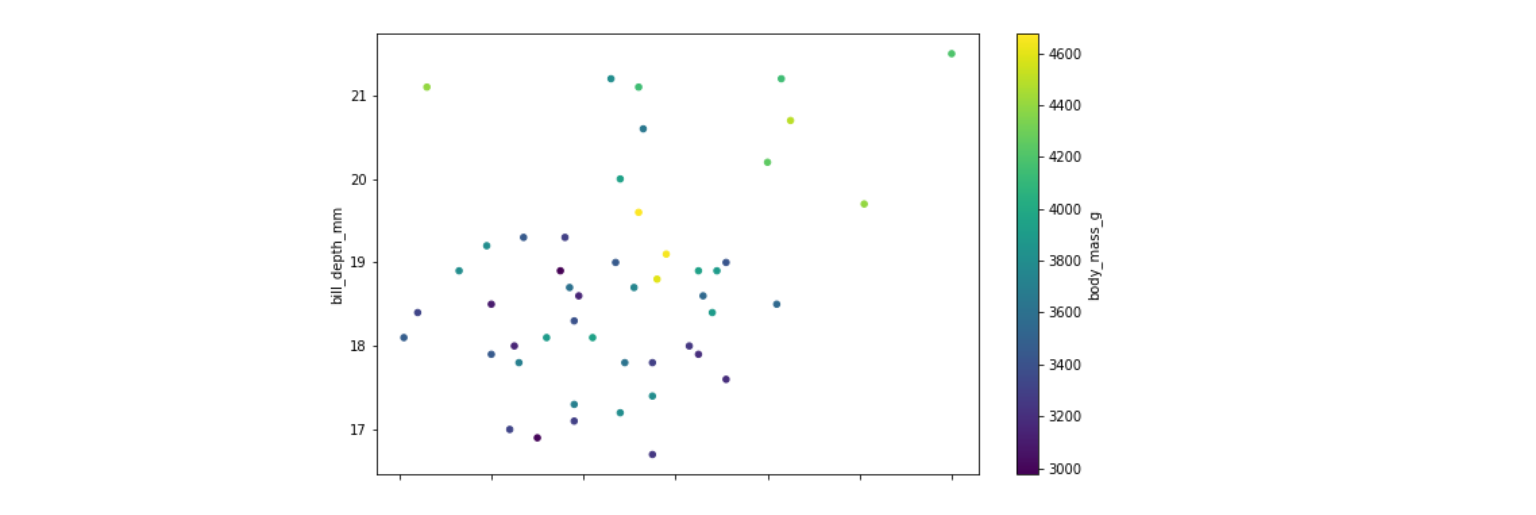

A scatter plot displays values for two numerical variables using cartesian coordinates. 
* The idea of a scatter plot is to understand the relationship between the variables and how they are distributed
* It is possible to add more variables to the plot when these additional variables are coded as colour, shape or size.

We will consider the 'penguins' dataset. It has records for three different species of penguins collected from 3 islands in the Palmer Archipelago, Antarctica

In [2]:
import seaborn as sns
df = sns.load_dataset('penguins')
df = df.sample(frac=0.33, random_state=1) # get a fraction of the data
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
306,Gentoo,Biscoe,43.4,14.4,218.0,4600.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
291,Gentoo,Biscoe,46.4,15.6,221.0,5000.0,Male
102,Adelie,Biscoe,37.7,16.0,183.0,3075.0,Female
289,Gentoo,Biscoe,50.7,15.0,223.0,5550.0,Male


Let's plot a scattor plot setting `kind='scatter'`, `x='bill_length_mm'` and `y='bill_depth_mm'`

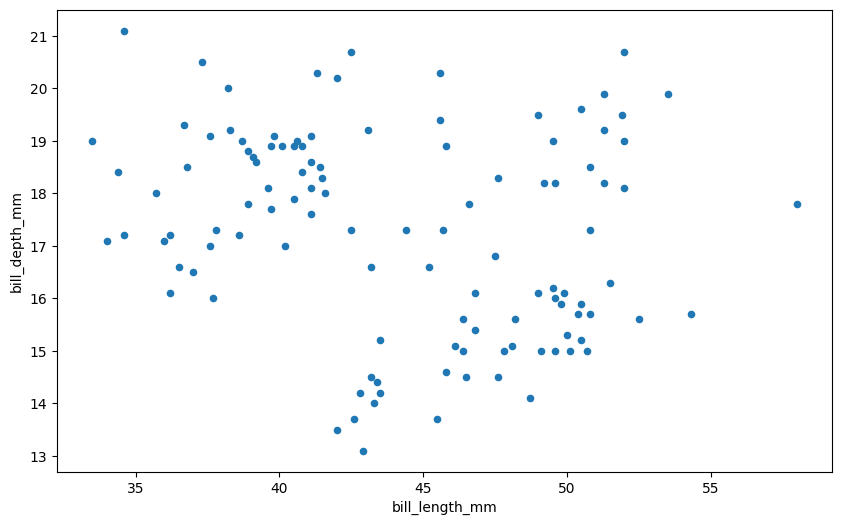

In [3]:
df.plot(kind='scatter',x='bill_length_mm',y='bill_depth_mm',figsize=(10,6))
plt.show()

You can add parameter `c` for colouring the plot based on another variable. The colour-map options are found [here](https://matplotlib.org/stable/tutorials/colors/colormaps.html). In this case, we set `c='body_mass_g'`

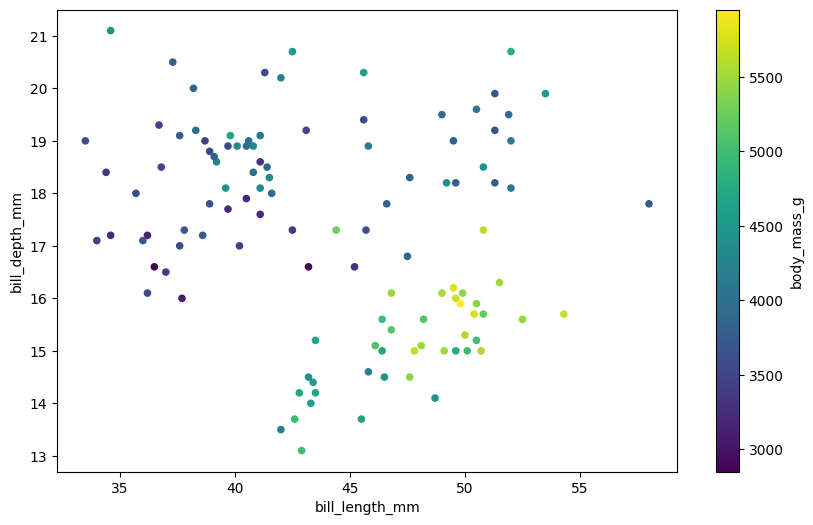

In [4]:
df.plot(kind='scatter',x='bill_length_mm',y='bill_depth_mm', c='body_mass_g',
        figsize=(10,6),colormap='viridis')
plt.show()

Now we added parameter `s`, for size. The dots' size will be defined according to body_mass_g levels.  We also set alpha=0.7, meaning we set the level to 70% of transparency. That gives a better look to the plot, so the dots will not be so cluttered.

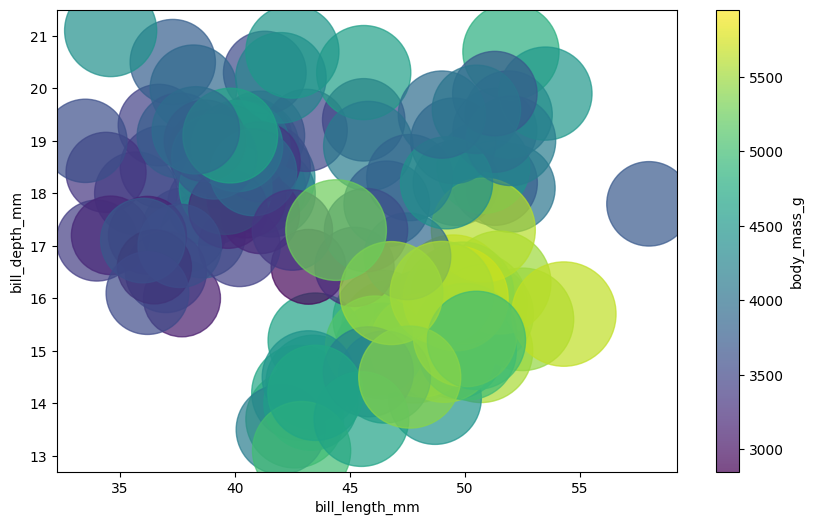

In [5]:
df.plot(kind='scatter',x='bill_length_mm',y='bill_depth_mm',
         c='body_mass_g',
        s=df['body_mass_g'],
        figsize=(10,6),
        colormap='viridis',
        alpha=0.7)
plt.show()

Note we divided `s` by 60 to scale better in the plot. 
* When you don't scale, the dots may be too big or small, so depending on the use case, it is worth dividing or multiplying by a factor.
*The best factor value is more like a trial and error exercise; try a random value and play around until you reach a visually nice plot composition.

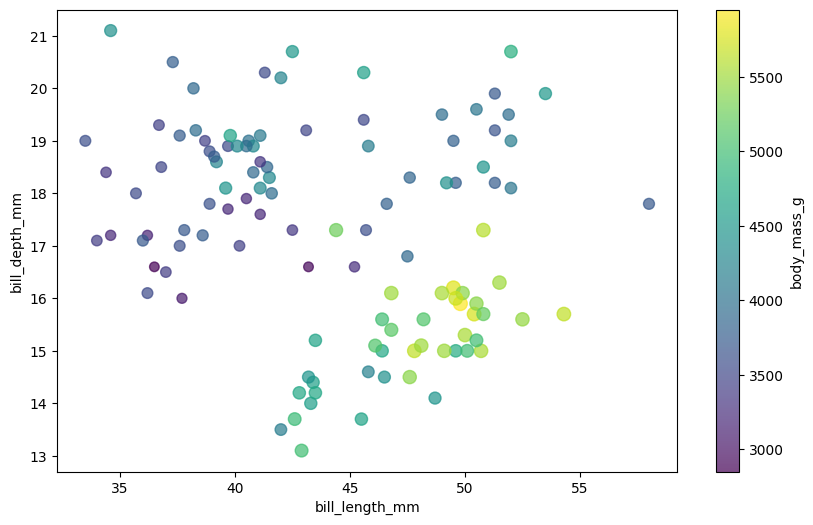

In [6]:
df.plot(kind='scatter',x='bill_length_mm',y='bill_depth_mm',
         c='body_mass_g',
        s=df['body_mass_g']/60,  ### factor by 60
        figsize=(10,6),
        colormap='viridis',
        alpha=0.7)
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png">

**PRACTICE**: We will consider the tips dataset for practice. It holds records for waiter tips based on the day of the week, time of day, total bill, gender, if it is a table of smokers or not, and how many people were at the table.


In [7]:
df_practice = sns.load_dataset('tips')
df_practice = df_practice.head(50)
df_practice.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


You are interested in using a scatter chart to display the value of tips received to the total bill amount.
* Use total_bill and tip for the x and y parameters and total_bill for the c parameter.
* Use the size column for the s parameter and viridis for the colourmap
* Choose values of your choice for the figsize.

<Axes: xlabel='total_bill', ylabel='tip'>

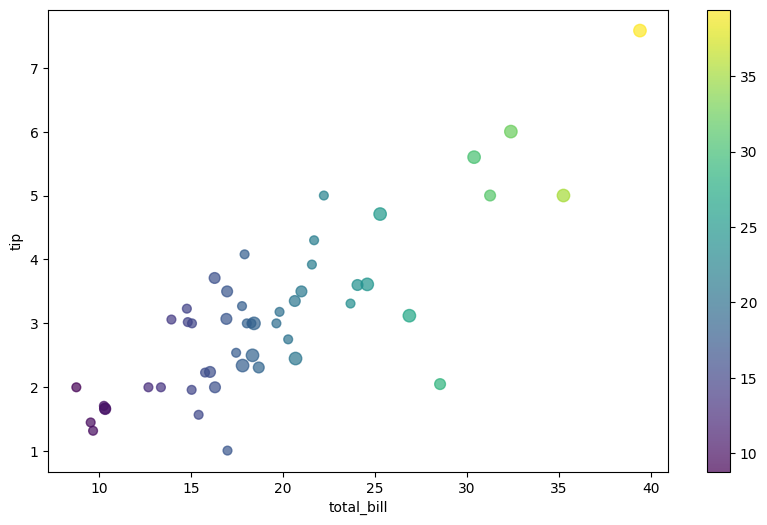

In [8]:
df_practice.plot(kind='scatter', 
                 x='total_bill', 
                 y='tip', 
                 s=df_practice['size']*20,
                 c=df_practice['total_bill'],
                 colormap='viridis',
                 alpha=0.7,
                 figsize=(10,6))

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Area Plot

An area plot is very similar to a line plot. The difference is that the area between the x-axis and the line is filled with colour or shading. It gives the evolution of a numeric variable


* We will consider a fictitious dataset considering Revenue, Margin and Volume

In [9]:
df = pd.DataFrame(data={'Revenue': [300, 350, 500, 250, 250, 350, 400],
                        'Margin': [150, 200, 400, 50, 180, 180, 200],
                        'Volume': [26, 30, 40, 15, 15, 30, 25],},
                  index=pd.date_range(start='2021/05/01',freq='D',periods=7))
df

,Revenue,Margin,Volume
2021-05-01,300,150,26
2021-05-02,350,200,30
2021-05-03,500,400,40
2021-05-04,250,50,15
2021-05-05,250,180,15
2021-05-06,350,180,30
2021-05-07,400,200,25


*Let*'s use kind='area' and y as a list with the variables you are interested in plotting.
* Note the values are stacked on each other, and for this context, it doesn't make much sense.
* Depending on the context of your variables, it could be worth stacking.

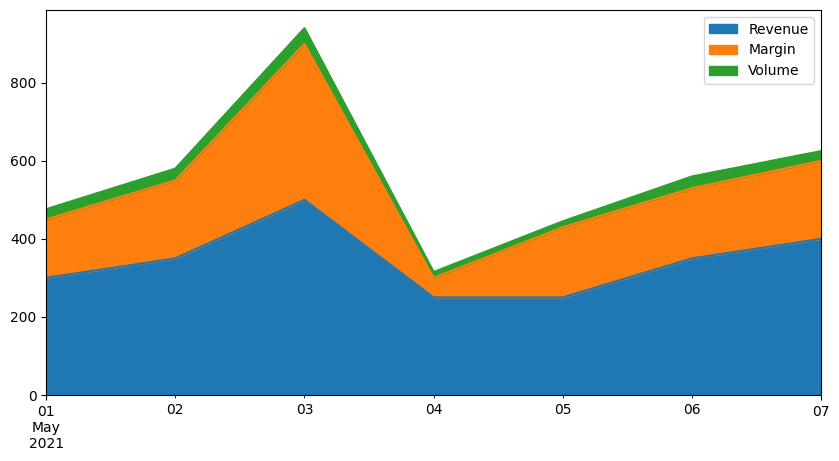

In [10]:
df.plot(kind='area', y=['Revenue','Margin', 'Volume'],figsize=(10,5))
plt.show()

*Let*'s use kind='area' and y as a list with the variables you are interested in plotting.
* Note the values are stacked on each other, and for this context, it doesn't make much sense.
* Depending on the context of your variables, it could be worth stacking.

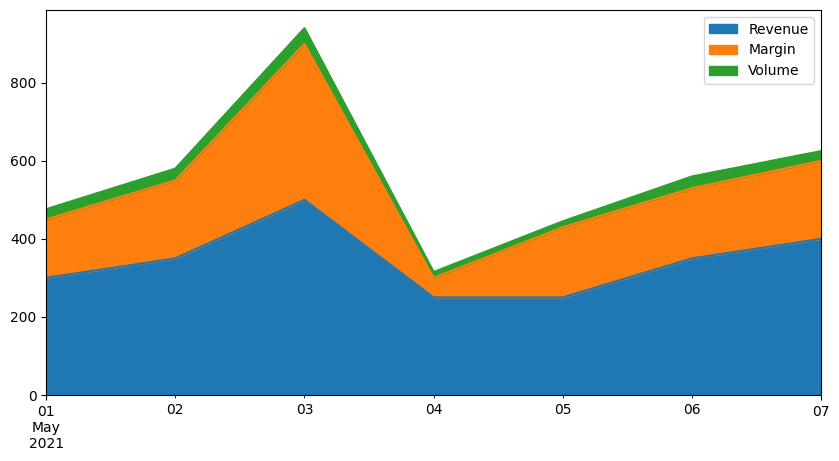

In [11]:
df.plot(kind='area', y=['Revenue','Margin', 'Volume'],figsize=(10,5))
plt.show()

You should add the argument ``stacked=False``, so the variables are not stacked in the plots. For this context, it makes more sense not to have the

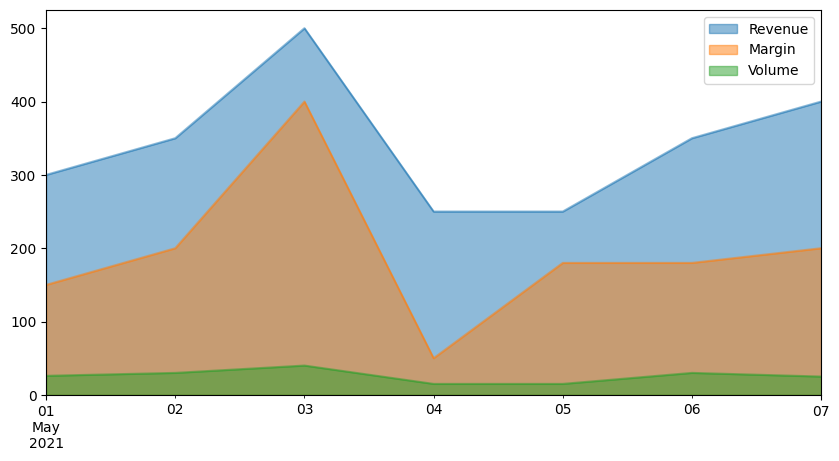

In [12]:
df.plot(kind='area', y=['Revenue','Margin', 'Volume'],figsize=(10,5),stacked=False)
plt.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will use UK MacroData to create an area chart.

In [13]:
df_practice = pd.read_csv("data/UK_MacroData.csv")
df_practice

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
0,2000 Q1,401242,1.1,5.875,69114.0
1,2000 Q2,404196,1.0,6.000,73074.0
2,2000 Q3,406795,1.2,6.000,68011.0
3,2000 Q4,409411,1.4,6.000,70115.0
4,2001 Q1,413054,1.3,5.750,70186.0
...,...,...,...,...,...
91,2022 Q4,568034,9.4,3.250,106689.0
92,2023 Q1,569336,9.0,4.125,109290.0
93,2023 Q2,569364,7.7,4.750,108245.0
94,2023 Q3,568655,6.3,5.250,106496.0


Using an area chart, having figsize of 10,5, Date for x, and not stacked, you would like to plot CPI and Bank Rates.

<Axes: xlabel='Date'>

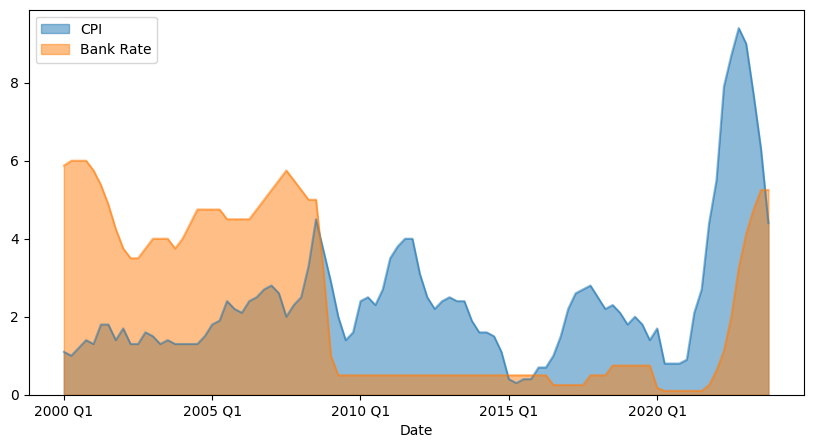

In [14]:
# Write your code here.
df_practice.plot(kind='area', y=['CPI', 'Bank Rate'], x='Date', figsize=(10,5), stacked=False)

Consider the result plot. Which date periods do Bank Rate and CPI areas swap at?

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Bar Plot

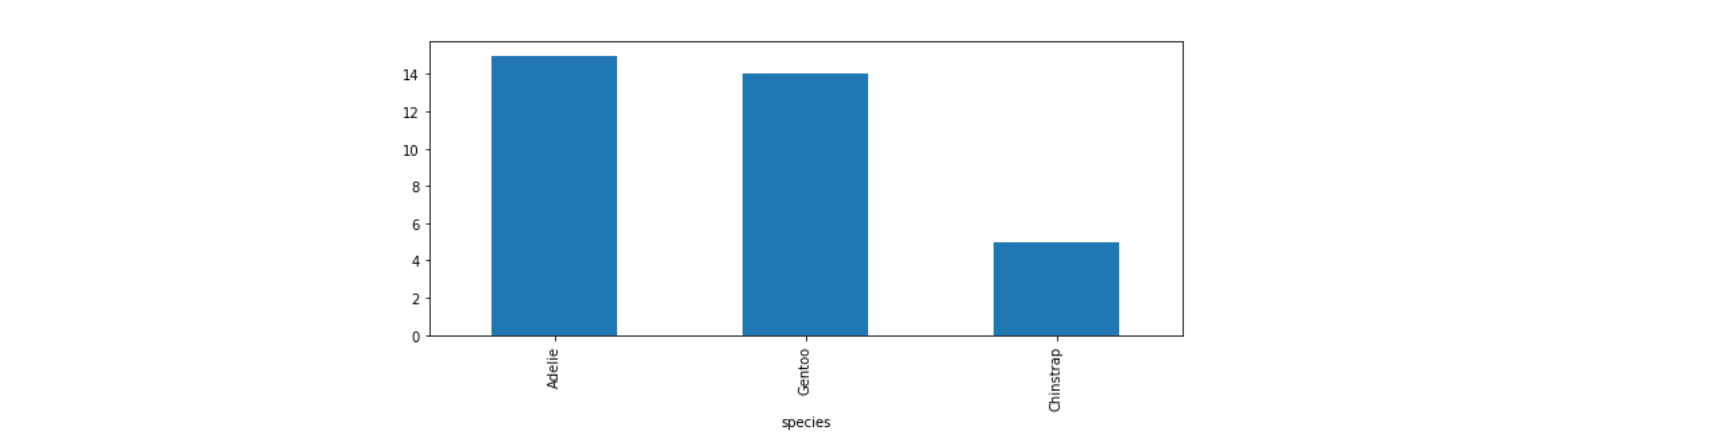

A Bar plot shows categorical data as bars with lengths proportional to the values they represent. Bar plots can be used to compare categories. In the x-axis, we find the categories being compared, and in the y-axis, their measured values.
In a bar chart, the data value is represented by the bar length, the larger the data, the larger the bar. This characteristic makes it easy for us to interpret data since we can easily distinguish lengths. Column or vertical bar charts, are the standard for bar charts.

* Let's consider the penguins' dataset. It has records for three different species of penguins collected from 3 islands in the Palmer Archipelago, Antarctica

In [15]:
df = sns.load_dataset('penguins')
df = df.sample(frac=0.1, random_state=1) # get a fraction of the data
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
306,Gentoo,Biscoe,43.4,14.4,218.0,4600.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
291,Gentoo,Biscoe,46.4,15.6,221.0,5000.0,Male
102,Adelie,Biscoe,37.7,16.0,183.0,3075.0,Female
289,Gentoo,Biscoe,50.7,15.0,223.0,5550.0,Male


We can plot the distribution of species. 
* First, we need to do a value_counts() of species as we need to be working with numerical data, and then we can plot.

In [16]:
df.value_counts('species')

species
Adelie       15
Gentoo       14
Chinstrap     5
Name: count, dtype: int64

Now we plot it using `kind='bar'`

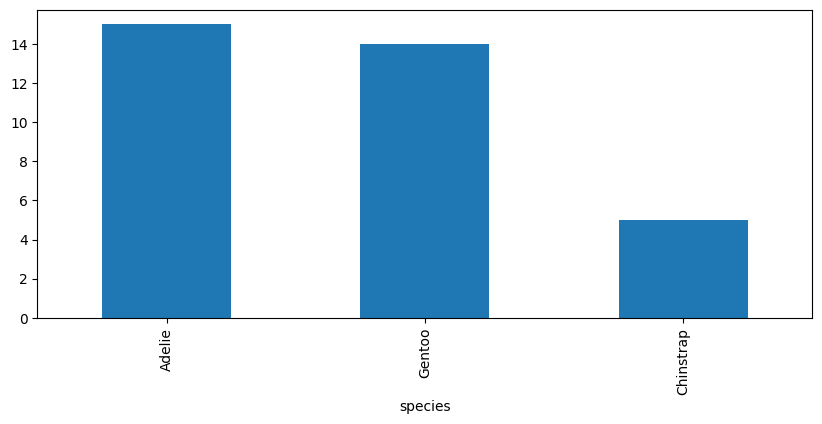

In [17]:
df.value_counts('species').plot(kind='bar',figsize=(10,4))
plt.show()

We can use `kind='barh'` to make horizontal bars. Horizontal bar charts are similar to column charts, but flipped on their side. They are better than the column charts when the names of the categories are long, because it is easier to read the labels.

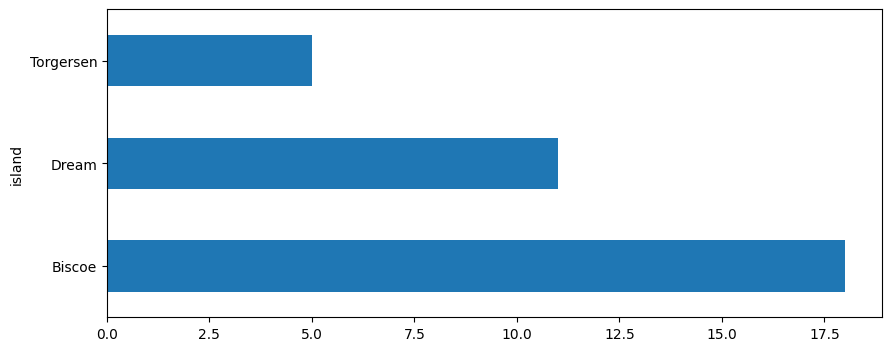

In [18]:
df.value_counts('island').plot(kind='barh',figsize=(10,4))
plt.show()

We may be interested in plotting all categorical variables in a dataset. For that, we combine a `for`, `.select_dtypes()` and `.value_counts().plot()`
* The logic is to loop only on variables that are object or categorical, and for these, plot the distribution levels

* species bar plot


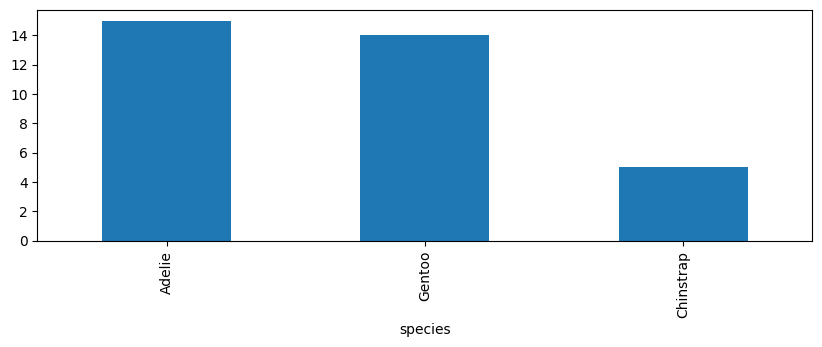




* island bar plot


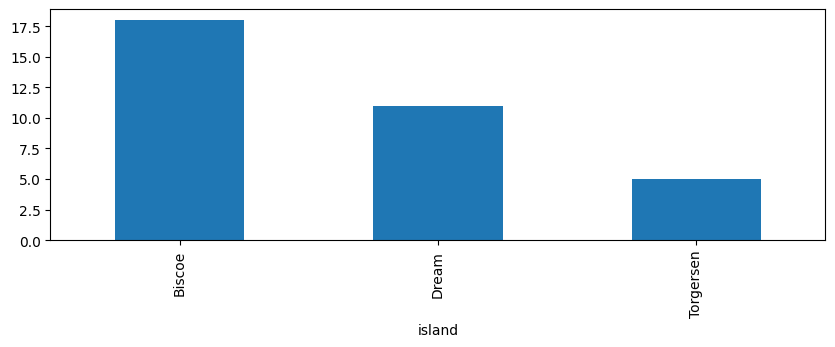




* sex bar plot


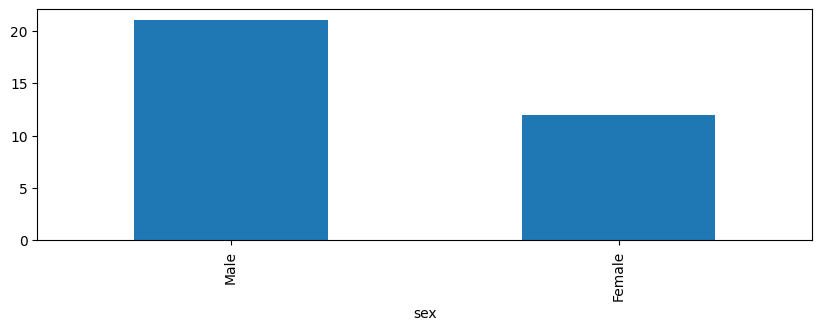

In [19]:
for col in df.select_dtypes(include='object').columns:
  df.value_counts(col).plot(kind='bar',figsize=(10,3))
  print(f"* {col} bar plot")
  plt.show()
  print("\n\n")

We may be interested in stacking categorical variables to another, such as showing species distribution across the islands. 
First we `groupby().size().unstack()` to get the data in a processed format for plotting

In [20]:
df.groupby(['island','species']).size().unstack()

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,4.0,NaN,14.0
Dream,6.0,5.0,NaN
Torgersen,5.0,NaN,NaN


Then we plot as we learned, but adding the parameter `stacked=True`

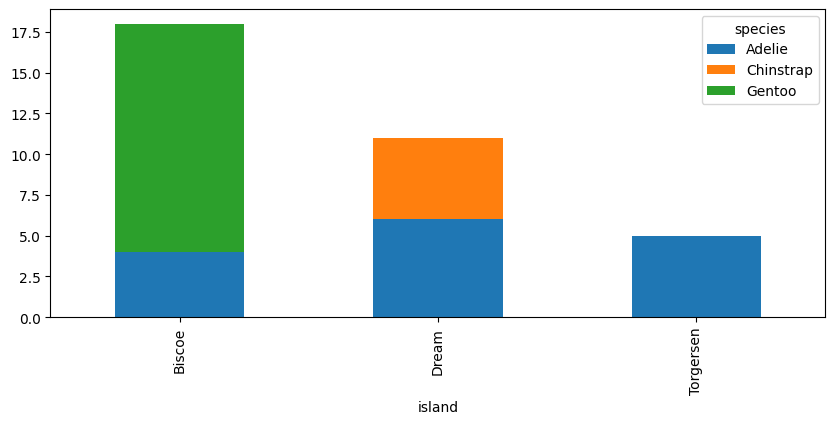

In [21]:
df.groupby(['island','species']).size().unstack().plot(kind='bar', stacked=True,figsize=(10,4))
plt.show()

We can loop over the categorical variables plotting the frequencies across the remaining categorical variables
* The logic uses a function called ``combinations`` that combine unique pairs of categorical variables and create a stacked bar plot

* species bar plot - stacked by island


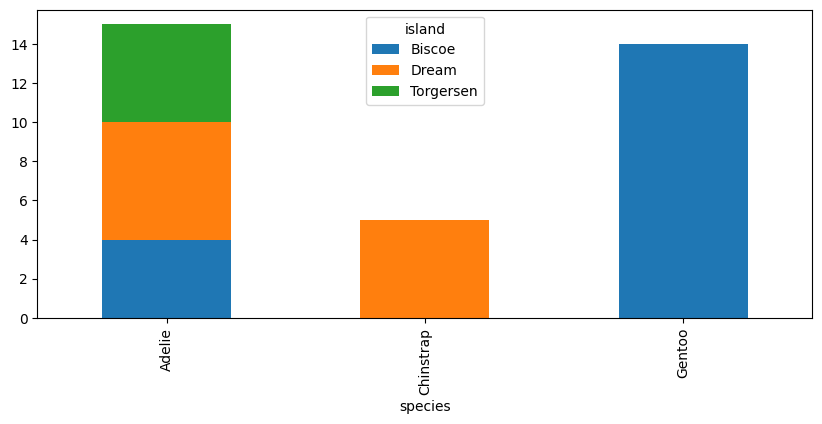




* species bar plot - stacked by sex


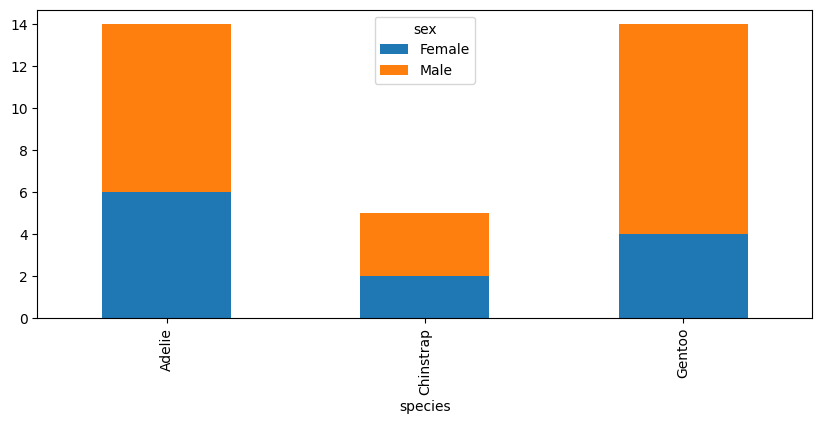




* island bar plot - stacked by sex


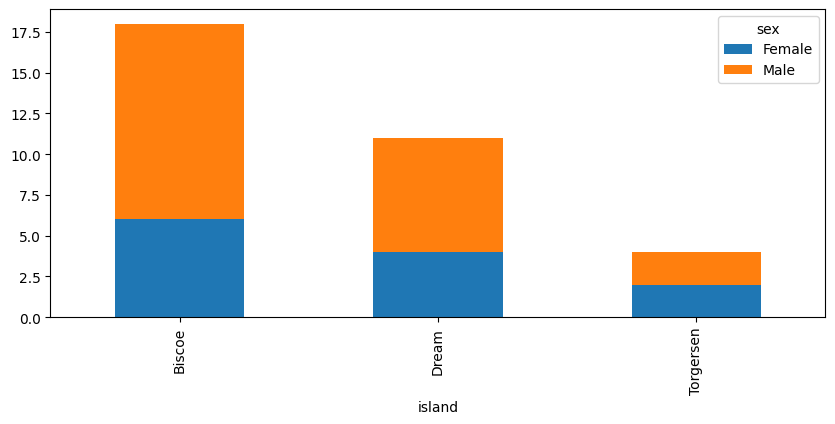

In [22]:
from itertools import combinations

for col1,col2 in combinations(df.select_dtypes(include='object').columns,2):
    print(f"* {col1} bar plot - stacked by {col2}")
    df.groupby([col1,col2]).size().unstack().plot(kind='bar', stacked=True,figsize=(10,4))
    plt.show()
    print('\n\n')


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will consider the tips dataset for practice. It holds records for waiter tips based on the day of the week, time of day, total bill, gender, if it is a table of smokers or not, and how many people were at the table.

In [23]:
df_practice = sns.load_dataset('tips')
df_practice.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


Feel free to try out your ideas or use the following suggestion.

You are interested in creating a stacked bar chart of categorical data grouped by day and time as you wish to easily see what times of the day are busiest at lunchtime or dinner time.

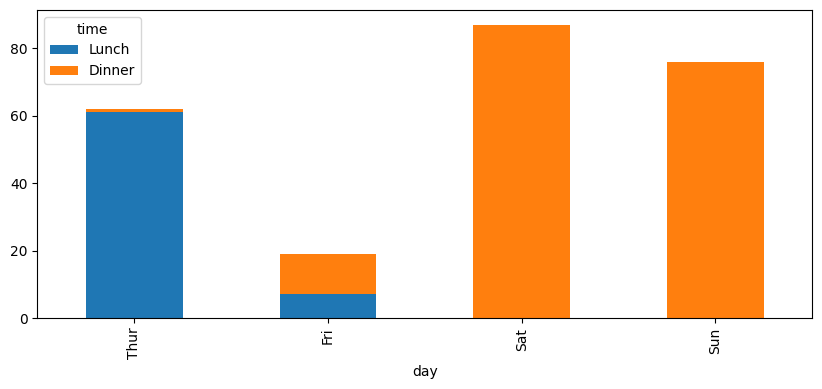

In [24]:
# Write your code here.
df_practice.groupby(['day','time'],observed=False).size().unstack().plot(kind='bar', stacked=True,figsize=(10,4))
plt.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">

###  Pie Chart

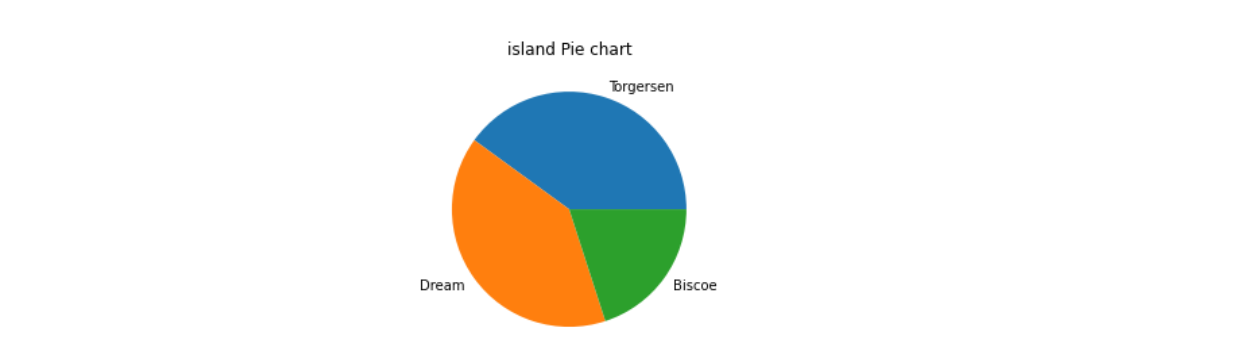

A pie chart shows the data composition. It is useful when the data is static, which means there is no variation over time. It is a proportional representation of categorical data. It is a circular plot where each slice represents one value and all slices add up to the whole. In the example above the whole represents all Penguins surveyed and each slice represents the percentage population of Penguins by Island. We should use pie charts when we want the audience to have a general sense of the part-to-whole relationship in your data. In this example it clearly shows Biscoe has the smallest population. Using pie charts is a simple way to present data, but it can be misleading because people have a hard time interpreting the relevant size of different slices of the pie. It's not immediately obvious which island has the largest population. In general, use pie charts if you have at most 3 or 4 values to present.


* Let's use the penguins' dataset. It has records for three different species of penguins collected from 3 islands in the Palmer Archipelago, Antarctica

In [25]:
df = sns.load_dataset('penguins')
df = df.head(50)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


First we count the frequencies for a given variable using `.value_counts()` using `normalize=True`, so we get the proportions

In [26]:
df.value_counts('sex',normalize=True)

sex
Female    0.5
Male      0.5
Name: proportion, dtype: float64

Then we plot using `kind='pie'`. `ylabel` is set to a blank space; otherwise, it would appear as 'None' on the left side of the plot. ``title`` is set to the variable name

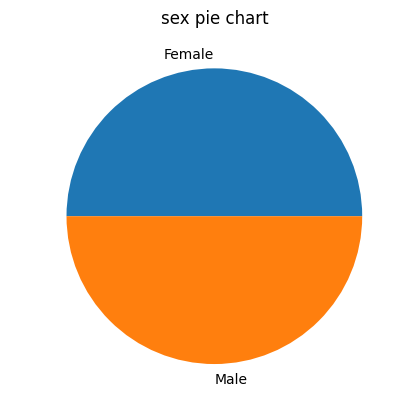

In [27]:
df.value_counts('sex',normalize=True).plot(kind='pie', ylabel=' ', title='sex pie chart')
plt.show()

We are again scanning over the categorical variables and making a pie plot using the previous use case

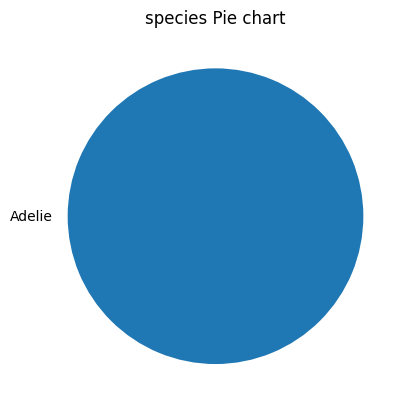

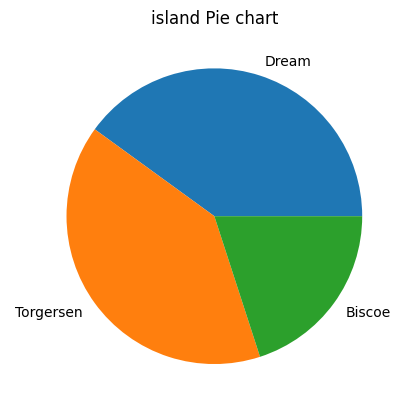

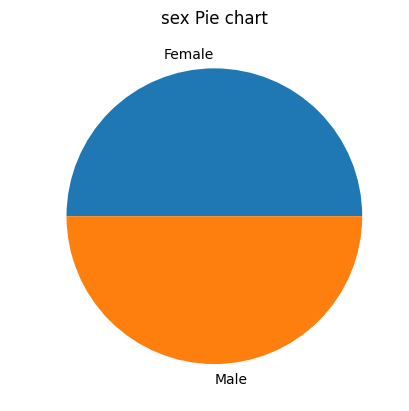

In [28]:
for col in df.select_dtypes(include='object').columns:
  df.value_counts(col,normalize=True).plot(kind='pie',ylabel=' ', title=f"{col} Pie chart")
  plt.show()
  print("\n\n")

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will consider the tips dataset for practice. It holds records for waiter tips based on the day of the week, time of day, total bill, gender, if it is a table of smokers or not, and how many people were at the table.

In [29]:
df_practice = sns.load_dataset('tips')
# there are some variables with data type of 'category', we replace for 'object
for col in df_practice.select_dtypes(include='category'):
  df_practice[col] = df_practice[col].astype('object')

df_practice.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


We are looking for pie charts of the categorical data from our DataFrame
* This will be the same as what you saw in the lesson material.

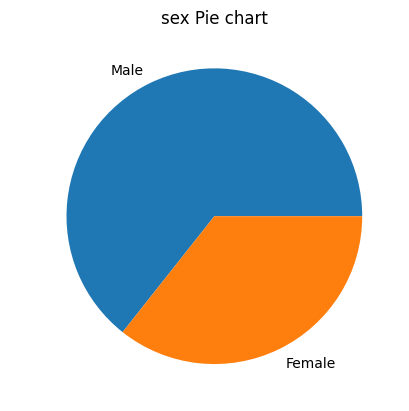

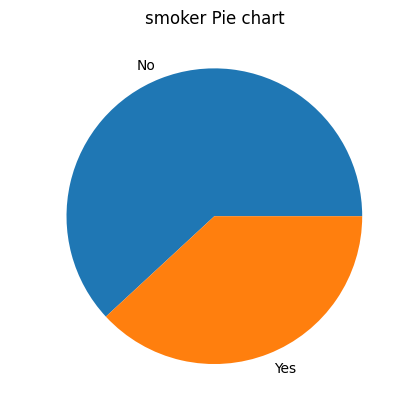

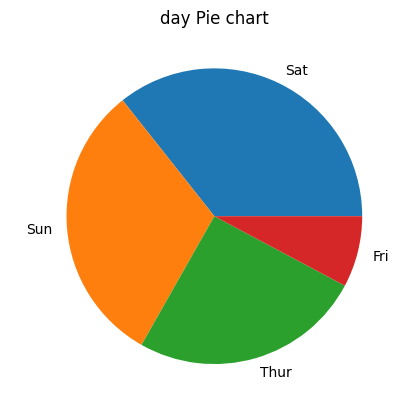

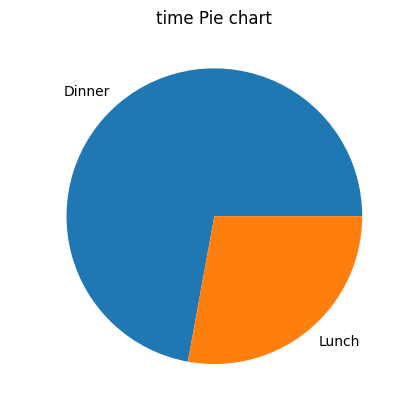

In [30]:
for col in df_practice.select_dtypes(include='object').columns:
  df_practice.value_counts(col,normalize=True).plot(kind='pie',ylabel=' ', title=f"{col} Pie chart")
  plt.show()
  print("\n\n")